In [7]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,Dropout,BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import os

In [8]:
x = pd.read_csv('fer2013.csv')
print (x.values.shape)

(35887, 3)


In [9]:
x.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [10]:
y = x.values[:,0]
pixels = x.values[:, 1]
print (type(pixels))
print (len(pixels))
print (len(pixels[0]))
print (pixels[10][10])

<class 'numpy.ndarray'>
35887
8287
3


In [11]:
p = pixels[10].split(' ')
print(len(p))

2304


In [12]:
X = np.zeros((pixels.shape[0], 48*48))

for ix in range(X.shape[0]):
    p = pixels[ix].split(' ')
    for iy in range(X.shape[1]):
        X[ix, iy] = int(p[iy])

In [13]:
temp = X

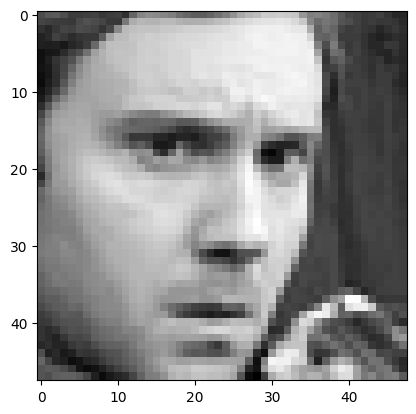

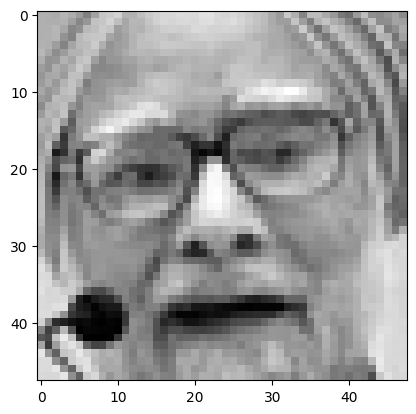

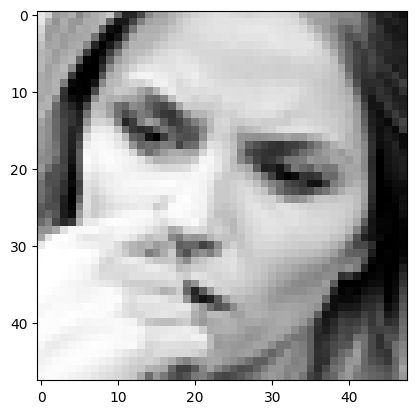

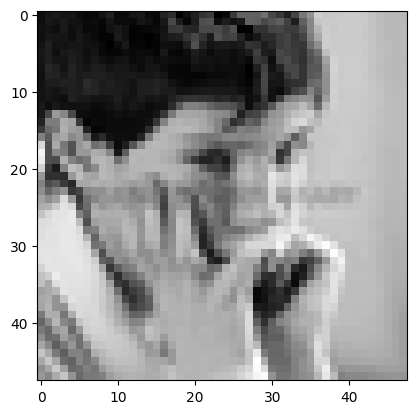

In [14]:
for ix in range(4):
    plt.figure(ix)
    plt.imshow(temp[ix].reshape((48, 48)), interpolation='none', cmap='gray')
plt.show()

In [15]:
X

array([[ 70.,  80.,  82., ..., 106., 109.,  82.],
       [151., 150., 147., ..., 193., 183., 184.],
       [231., 212., 156., ...,  88., 110., 152.],
       ...,
       [ 17.,  17.,  16., ..., 154., 133., 113.],
       [ 30.,  28.,  28., ...,  35.,  30.,  28.],
       [ 19.,  13.,  14., ..., 189., 199., 201.]], shape=(35887, 2304))

In [16]:
y

array([0, 0, 2, ..., 0, 3, 2], shape=(35887,), dtype=object)

In [17]:
X=X/255

In [18]:
X

array([[0.2745098 , 0.31372549, 0.32156863, ..., 0.41568627, 0.42745098,
        0.32156863],
       [0.59215686, 0.58823529, 0.57647059, ..., 0.75686275, 0.71764706,
        0.72156863],
       [0.90588235, 0.83137255, 0.61176471, ..., 0.34509804, 0.43137255,
        0.59607843],
       ...,
       [0.06666667, 0.06666667, 0.0627451 , ..., 0.60392157, 0.52156863,
        0.44313725],
       [0.11764706, 0.10980392, 0.10980392, ..., 0.1372549 , 0.11764706,
        0.10980392],
       [0.0745098 , 0.05098039, 0.05490196, ..., 0.74117647, 0.78039216,
        0.78823529]], shape=(35887, 2304))

In [19]:
X_train = X[0:30000, :]
Y_train = y[0:30000]
print (X_train.shape, Y_train.shape)

X_test = X[30000:32300,:]
Y_test = y[30000:32300]
print (X_test.shape, Y_test.shape)

(30000, 2304) (30000,)
(2300, 2304) (2300,)


In [20]:
X_train = X_train.reshape((X_train.shape[0], 48, 48,1 ))
X_test  = X_test.reshape((X_test.shape[0], 48, 48,1))

In [21]:
Y_train = to_categorical(Y_train)
Y_test  = to_categorical(Y_test)
print(Y_train.shape)
print(Y_test.shape)

(30000, 7)
(2300, 7)


In [22]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
lr_reduce = ReduceLROnPlateau(monitor='val_acc', factor=0.1, epsilon=0.0001, patience=1, verbose=1)

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
        featurewise_center=False,  
        samplewise_center=False,  
        featurewise_std_normalization=False,  
        samplewise_std_normalization=False,  
        zca_whitening=False,  
        rotation_range=10,  
        zoom_range = 0.0,  
        width_shift_range=0.1,  
        height_shift_range=0.1,  
        horizontal_flip=False, 
        vertical_flip=False)  

datagen.fit(X_train)

In [25]:
model = Sequential()

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(48,48,1)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.22))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam' ,
              metrics=['acc'])

print(model.summary())

D:\Emotion-Detection-FER2013\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 44, 44, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441,223 (5.50 MB)

 Trainable params: 1,441,223 (5.50 MB)

 Non-trainable params: 0 (0.00 B)

None


In [26]:
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7) ,
              metrics=['acc'])

In [27]:
batch_size = 64
epochs = 40

# steps_per_epoch = len(X) // batch_size
# validation_steps = len((X_test, Y_test)) // batch_size

In [28]:
history = model.fit(X_train, Y_train, 
                    batch_size=batch_size,
                    validation_data=(X_test, Y_test),
                    epochs = epochs,
                    shuffle=True, 
                    verbose = 2)

Epoch 1/40
469/469 - 60s - 127ms/step - acc: 0.2608 - loss: 1.7927 - val_acc: 0.3500 - val_loss: 1.6637
Epoch 2/40
469/469 - 55s - 117ms/step - acc: 0.3776 - loss: 1.5812 - val_acc: 0.4543 - val_loss: 1.3975
Epoch 3/40
469/469 - 56s - 120ms/step - acc: 0.4576 - loss: 1.3994 - val_acc: 0.5043 - val_loss: 1.2747
Epoch 4/40
469/469 - 55s - 118ms/step - acc: 0.4993 - loss: 1.3056 - val_acc: 0.5465 - val_loss: 1.2036
Epoch 5/40
469/469 - 56s - 119ms/step - acc: 0.5271 - loss: 1.2432 - val_acc: 0.5404 - val_loss: 1.1642
Epoch 6/40
469/469 - 56s - 120ms/step - acc: 0.5461 - loss: 1.1984 - val_acc: 0.5591 - val_loss: 1.1349
Epoch 7/40
469/469 - 58s - 124ms/step - acc: 0.5623 - loss: 1.1583 - val_acc: 0.5504 - val_loss: 1.1536
Epoch 8/40
469/469 - 61s - 129ms/step - acc: 0.5748 - loss: 1.1243 - val_acc: 0.5622 - val_loss: 1.1171
Epoch 9/40
469/469 - 57s - 121ms/step - acc: 0.5846 - loss: 1.0932 - val_acc: 0.5865 - val_loss: 1.1013
Epoch 10/40
469/469 - 56s - 120ms/step - acc: 0.5954 - loss: 1.0

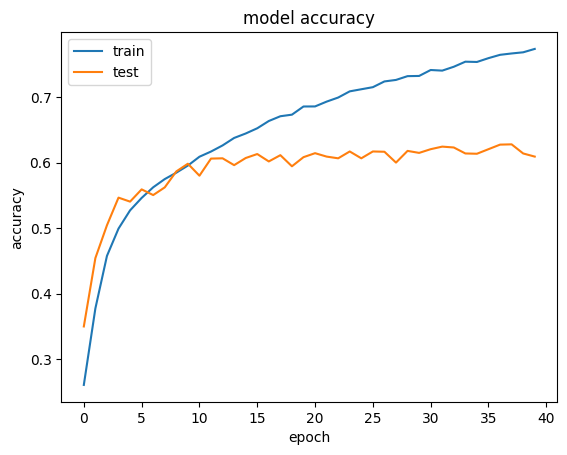

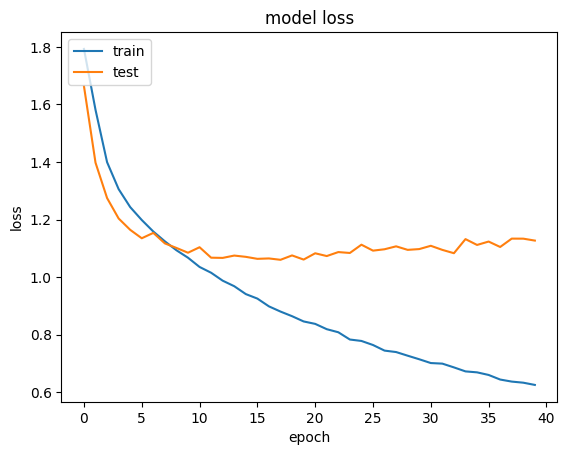

In [29]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [30]:
model.save('emotion_detection_model.h5')

In [31]:
# ---------------------------------------
# Evaluate model accuracy after real-time loop
# ---------------------------------------

import pandas as pd
from tensorflow.keras.utils import to_categorical
import numpy as np

print("\nEvaluating model accuracy on FER-2013 test split...\n")

# Load csv
x = pd.read_csv('fer2013.csv')
y = x.values[:, 0]
pixels = x.values[:, 1]

# Convert pixel strings to array
X = np.zeros((pixels.shape[0], 48*48))
for i in range(X.shape[0]):
    p = pixels[i].split(' ')
    X[i] = np.array(p, dtype='float32')

# Normalize
X = X / 255.0

# Use the SAME split as training
X_test = X[30000:32300, :].reshape(-1, 48, 48, 1)
Y_test = to_categorical(y[30000:32300])

loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"Test Accuracy: {acc * 100:.2f}%")



Evaluating model accuracy on FER-2013 test split...

Test Accuracy: 60.91%


In [33]:
# -------------------------------
# MODEL FIT DIAGNOSIS (OVER/UNDERFITTING)
# -------------------------------

import numpy as np

def diagnose_fit(history, acc_key='acc', val_acc_key='val_acc', loss_key='loss', val_loss_key='val_loss'):
    hist = history.history

    train_acc = np.array(hist.get(acc_key, []))
    val_acc   = np.array(hist.get(val_acc_key, []))
    train_loss = np.array(hist.get(loss_key, []))
    val_loss   = np.array(hist.get(val_loss_key, []))

    if len(train_acc) == 0 or len(val_acc) == 0:
        print("⚠️ No accuracy data available to diagnose.")
        return

    # Last epoch values
    t_acc = train_acc[-1]
    v_acc = val_acc[-1]
    t_loss = train_loss[-1] if len(train_loss) > 0 else None
    v_loss = val_loss[-1] if len(val_loss) > 0 else None

    gap_acc = t_acc - v_acc

    print("\n================ DIAGNOSIS ================")
    print(f"Final Train Acc : {t_acc * 100:.2f}%")
    print(f"Final Val Acc   : {v_acc * 100:.2f}%")
    print(f"Accuracy Gap    : {gap_acc * 100:.2f}%")

    if t_loss is not None:
        print(f"Final Train Loss: {t_loss:.4f}")
        print(f"Final Val Loss  : {v_loss:.4f}")

    # ---------- RULES ----------
    # Underfitting
    if t_acc < 0.6 and v_acc < 0.6:
        print("📉 Model is UNDERFITTING.")
        print("➡ Increase epochs, add more filters/layers, or improve data quality.")
        return

    # Overfitting (strong)
    if t_acc > 0.9 and v_acc < 0.7 and gap_acc > 0.15:
        print("🔥 Model is OVERFITTING heavily.")
        print("➡ Increase dropout, add L2 regularization, or apply stronger augmentation.")
        return

    # Overfitting (mild)
    if gap_acc > 0.10:
        print("⚠️ Model shows mild OVERFITTING.")
        print("➡ Slightly increase dropout or augmentation.")
        return

    # Good fit
    if t_acc >= 0.7 and v_acc >= 0.7 and abs(gap_acc) <= 0.10:
        print("✅ Model is WELL-FITTED.")
        print("➡ Train and validation are balanced.")
        return

    print("ℹ️ Diagnosis inconclusive. Check graphs manually.")
    print("=============================================\n")

# ---- CALL THE FUNCTION ----
diagnose_fit(history)



================ DIAGNOSIS ================
Final Train Acc : 77.34%
Final Val Acc   : 60.91%
Accuracy Gap    : 16.43%
Final Train Loss: 0.6254
Final Val Loss  : 1.1269
⚠️ Model shows mild OVERFITTING.
➡ Slightly increase dropout or augmentation.
